# Lab 2: Student Dropout Classification

**Zhan Tabuldinov, BDA-2401**

The recommended topic was customer churn. The task allows another classification problem related to the major, so I chose a very similar problem for a university: **predict whether a student will drop out** (the "churn" of a student). For a university a student who leaves is the same as a lost customer: lost tuition, lost state grant and worse rankings.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
sns.set_theme(style="whitegrid")

## 1. Dataset Selection

**Dataset:** Predict students' dropout and academic success (Kaggle, uploaded by The Devastator; original data from a Portuguese university, Realinho et al., 2022, license CC0).
**Link:** https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention

**Why it is relevant to my major:** universities collect a lot of data about students (admission, payments, grades, social status). Big Data Analytics is used to turn this data into an early-warning system for students at risk. It is the same idea as customer churn, but the "customer" is a student.

* **Target:** `Target` – Dropout / Graduate / Enrolled. I convert it to a binary target `dropout` (1 = Dropout, 0 = Graduate).
* **Input features:** 34 columns – demographic (age, gender, marital status), socio-economic (scholarship, debtor, tuition fees paid, parents' education), academic (course, application mode, units enrolled / approved / grade in the 1st and 2nd semester) and macro-economic (unemployment, inflation, GDP).
* **Observations:** 4 424 students, 35 columns (34 features + target).

In [2]:
import kagglehub
path = kagglehub.dataset_download("thedevastator/higher-education-predictors-of-student-retention")
df = pd.read_csv(path + "/dataset.csv")
print(df.shape)
df.head()

(4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Business Understanding

* **Problem.** Every year part of first-year students leave the university. The university learns about it too late, when the student has already stopped paying and attending.
* **What the model predicts.** After the first year (two semesters) the model gives for every student the probability that they will drop out instead of graduating.
* **Who will use it.** The dean's office and student advisors (to call the student and offer help), the financial aid office (to offer a scholarship or a payment plan), the university management (to plan the budget).
* **How it helps.** One phone call or a meeting with an advisor is cheap; a lost student is expensive (tuition for 2–3 more years, a state grant, a worse place in rankings). If the model finds most students at risk early, the university can keep some of them. This is the same logic as customer retention in business.

**Success criteria (defined before modelling), on the test set:**

| Metric | Threshold | Reason |
|---|---|---|
| Recall (dropout class) | ≥ 0.80 | we must find at least 80 % of students who will really drop out – a missed student is the most expensive error |
| F1-score | ≥ 0.80 | recall must not be reached by marking everyone as "at risk"; precision also matters because advisors have limited time |
| Accuracy | > 0.61 | must be better than the naive model "nobody drops out" (61 % of students graduate) |

The most important metric is **recall**, the second is **F1**.

**Short glossary.** *Classification* – predicting a class (yes / no). *Accuracy* – share of correct predictions. *Precision* – of all students predicted as dropout, how many really dropped out. *Recall* – of all real dropouts, how many the model found. *F1* – harmonic mean of precision and recall. *Confusion matrix* – table of true / false positives and negatives. *Logistic regression* – linear model that gives a probability of the class. *Decision tree* – model that splits the data by simple rules. *One-hot encoding* – categories into 0/1 columns. *Data leakage* – using test information in training.

## 3. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.18,0.61,1.00,1.00,1.00,1.00,6.00
Application mode,4424.0,6.89,5.30,1.00,1.00,8.00,12.00,18.00
Application order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Course,4424.0,9.90,4.33,1.00,6.00,10.00,13.00,17.00
Daytime/evening attendance,4424.0,0.89,0.31,0.00,1.00,1.00,1.00,1.00
Previous qualification,4424.0,2.53,3.96,1.00,1.00,1.00,1.00,17.00
Nacionality,4424.0,1.25,1.75,1.00,1.00,1.00,1.00,21.00
Mother's qualification,4424.0,12.32,9.03,1.00,2.00,13.00,22.00,29.00
Father's qualification,4424.0,16.46,11.04,1.00,3.00,14.00,27.00,34.00
Mother's occupation,4424.0,7.32,4.00,1.00,5.00,6.00,10.00,32.00


The data has 4 424 rows and 35 columns, no missing values. All features are numbers: binary flags (0/1), counts and grades, and **coded categories** (for example `Course` = 1…17, `Application mode` = 1…18, `Marital status` = 1…6 – the codes are explained in the dataset description). Only `Target` is text.

Some facts from the summary: age at enrollment is 17–70 (median 20), grades are on the Portuguese 0–20 scale, students take 5–7 units per semester on average, about 11 % are debtors, 12 % have not paid tuition on time, 25 % have a scholarship.

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


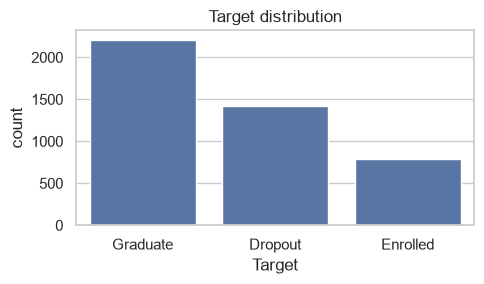

In [5]:
print(df["Target"].value_counts())
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x="Target", order=["Graduate", "Dropout", "Enrolled"], color="#4C72B0")
plt.title("Target distribution"); plt.tight_layout(); plt.show()

**Figure 1.** 2 209 students graduated, 1 421 dropped out and 794 are still enrolled. "Enrolled" students have no final result yet, so they are removed in cleaning. After that the classes are Graduate 61 % / Dropout 39 % – a moderate imbalance, it does not need special methods, but accuracy alone is not enough to judge the model.

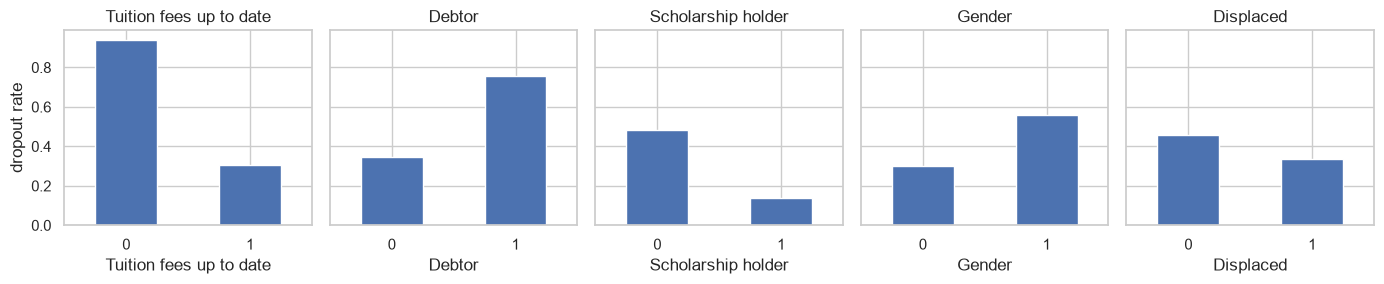

In [6]:
b = df[df["Target"] != "Enrolled"].copy()
b["dropout"] = (b["Target"] == "Dropout").astype(int)
cols = ["Tuition fees up to date", "Debtor", "Scholarship holder", "Gender", "Displaced"]
fig, ax = plt.subplots(1, 5, figsize=(14, 3), sharey=True)
for a, c in zip(ax, cols):
    b.groupby(c)["dropout"].mean().plot.bar(ax=a, color="#4C72B0", rot=0)
    a.set(title=c, ylabel="dropout rate")
plt.tight_layout(); plt.show()

**Figure 2.** Money is the strongest social factor: 94 % of students who did not pay tuition on time dropped out (vs 31 % of those who paid), 76 % of debtors dropped out. Scholarship holders almost never leave (14 % vs 48 %). Men drop out more often than women (56 % vs 30 %). `Gender` is coded 1 = male, 0 = female.

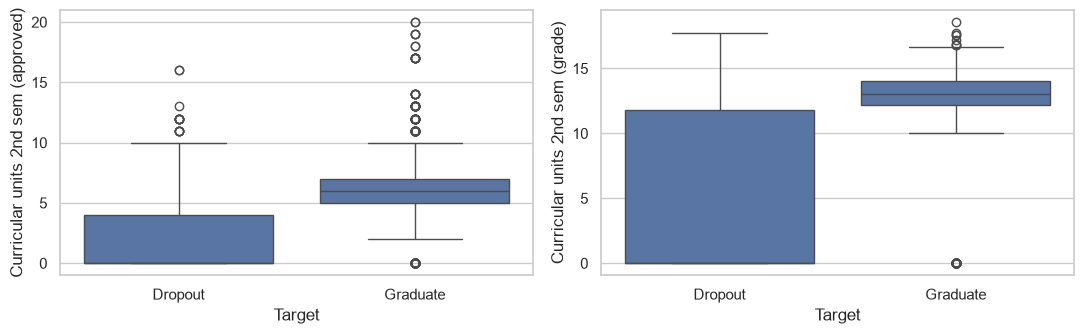

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(data=b, x="Target", y="Curricular units 2nd sem (approved)", ax=ax[0], color="#4C72B0")
sns.boxplot(data=b, x="Target", y="Curricular units 2nd sem (grade)", ax=ax[1], color="#4C72B0")
plt.tight_layout(); plt.show()

**Figure 3.** Academic results separate the classes very well. Graduates pass 5–6 units in the 2nd semester with a grade around 12–14; dropouts pass a median of 2 units and many have a grade of 0 (nothing passed). This means the model will be quite accurate, but it also means we can only predict at the end of the first year.

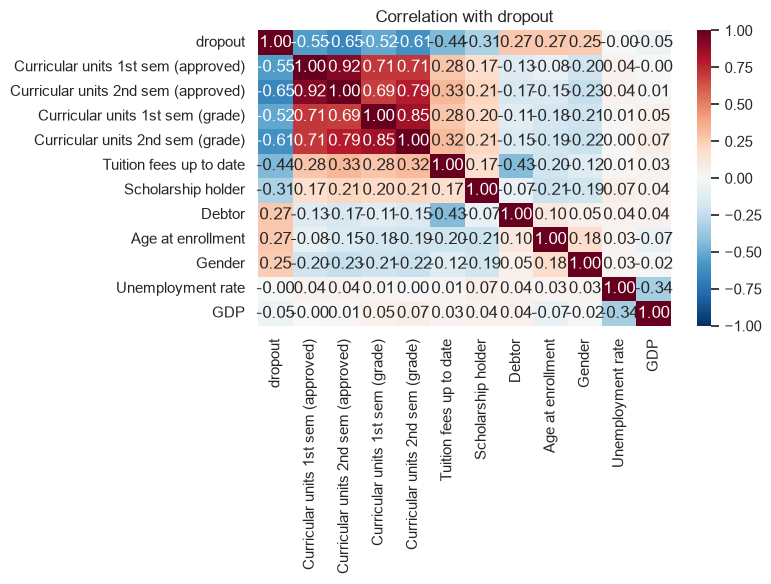

In [8]:
num = ["dropout", "Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)", "Curricular units 1st sem (grade)",
       "Curricular units 2nd sem (grade)", "Tuition fees up to date", "Scholarship holder", "Debtor", "Age at enrollment", "Gender", "Unemployment rate", "GDP"]
plt.figure(figsize=(8, 6))
sns.heatmap(b[num].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation with dropout"); plt.tight_layout(); plt.show()

**Figure 4.** The strongest correlations with dropout are the number of approved units in the 2nd semester (−0.65) and 1st semester (−0.55), the grades (−0.61 / −0.52), tuition paid (−0.44) and scholarship (−0.31). Age (+0.27), debtor (+0.27) and gender (+0.25) increase the risk. Macro-economic features (unemployment, GDP) have almost zero correlation. The academic features are correlated with each other (approved units and grade, 1st and 2nd semester), which is normal.

## 4. Data Cleaning

In [9]:
print("missing values:", df.isna().sum().sum(), "| duplicates:", df.duplicated().sum())
print("non-numeric columns:", list(df.select_dtypes(exclude="number").columns))
print("approved > enrolled (1st sem):", (df["Curricular units 1st sem (approved)"] > df["Curricular units 1st sem (enrolled)"]).sum())
print("grades outside 0-20:", ((df["Curricular units 1st sem (grade)"] > 20) | (df["Curricular units 2nd sem (grade)"] > 20)).sum())
print("age outside 17-70:", (~df["Age at enrollment"].between(17, 70)).sum())
print("students with 0 enrolled units in both semesters:", ((df["Curricular units 1st sem (enrolled)"] == 0) & (df["Curricular units 2nd sem (enrolled)"] == 0)).sum())
print("age >= 50:", (df["Age at enrollment"] >= 50).sum())

missing values: 0 | duplicates: 0
non-numeric columns: ['Target']
approved > enrolled (1st sem): 0
grades outside 0-20: 0
age outside 17-70: 0
students with 0 enrolled units in both semesters: 180
age >= 50: 59


* **Missing values and duplicates:** none.
* **Data types:** all columns are numeric; the coded categories (`Course`, `Application mode`, `Marital status`, `Previous qualification`) will be one-hot encoded in preprocessing so that the model does not treat code 12 as "bigger" than code 3.
* **Invalid values:** none – approved units are never bigger than enrolled units, grades are inside 0–20, ages are inside 17–70.
* **Inconsistency:** 180 students have 0 enrolled units in both semesters (they never really started). I keep them – half of them dropped out, so this is useful information, and the new feature `approval_rate` will be 0 for them.
* **Outliers:** 59 students are 50 or older. These are real adult students, not errors, so they are kept.
* **Column name:** `Nacionality` is a typo, renamed to `Nationality`.
* **Target:** 794 "Enrolled" students are removed because their result is not known yet.

In [10]:
before = len(df)
df = df.rename(columns={"Nacionality": "Nationality"})
df = df[df["Target"] != "Enrolled"].copy()
df["dropout"] = (df["Target"] == "Dropout").astype(int)
print("rows before:", before, "-> after:", len(df))
print(df["dropout"].value_counts(normalize=True).round(3))

rows before: 4424 -> after: 3630
dropout
0    0.609
1    0.391
Name: proportion, dtype: float64


## 5. Feature Engineering

**Removed features (with reason):**

| Feature | Why removed |
|---|---|
| `Nationality`, `International` | 97.5 % of students are Portuguese, almost no variation |
| `Educational special needs` | only 51 students (1 %) have it |
| `Mother's / Father's qualification and occupation` | 4 coded columns with 29–46 codes each, correlation with dropout ≈ 0 |
| `Unemployment rate`, `Inflation rate`, `GDP` | macro-economic values of the year, the same for all students of one year, correlation ≈ 0 |
| `Curricular units … (credited)`, `… (without evaluations)` | rare and weak (correlation < 0.1), and partly duplicated by enrolled / approved counts |
| `Target` | replaced by the binary `dropout` |

**Created features:**

| Feature | Formula | Why it helps |
|---|---|---|
| `approval_rate_1st` | approved / enrolled units, 1st semester | the share of passed units is a fairer measure than the count: 3 of 3 is better than 3 of 7 |
| `approval_rate_2nd` | approved / enrolled units, 2nd semester | same for the 2nd semester (0 if nothing enrolled) |
| `financial_risk` | 1 if debtor **or** tuition not paid on time | one simple flag for "money problems", easy to use by the financial aid office |

Kept: demographic flags, age, course and application codes, counts and grades of both semesters, scholarship, debtor and tuition flags.

In [11]:
e1, a1 = df["Curricular units 1st sem (enrolled)"], df["Curricular units 1st sem (approved)"]
e2, a2 = df["Curricular units 2nd sem (enrolled)"], df["Curricular units 2nd sem (approved)"]
df["approval_rate_1st"] = (a1 / e1.replace(0, np.nan)).fillna(0)
df["approval_rate_2nd"] = (a2 / e2.replace(0, np.nan)).fillna(0)
df["financial_risk"] = ((df["Debtor"] == 1) | (df["Tuition fees up to date"] == 0)).astype(int)
drop = ["Target", "Nationality", "International", "Educational special needs", "Mother's qualification", "Father's qualification",
        "Mother's occupation", "Father's occupation", "Unemployment rate", "Inflation rate", "GDP",
        "Curricular units 1st sem (credited)", "Curricular units 2nd sem (credited)",
        "Curricular units 1st sem (without evaluations)", "Curricular units 2nd sem (without evaluations)"]
df = df.drop(columns=drop)
print(df.shape)
print(df[["approval_rate_1st", "approval_rate_2nd", "financial_risk", "dropout"]].corr()["dropout"].round(2))

(3630, 24)
approval_rate_1st   -0.67
approval_rate_2nd   -0.74
financial_risk       0.42
dropout              1.00
Name: dropout, dtype: float64


The new features are among the strongest: correlation with dropout is −0.67 (`approval_rate_1st`), −0.74 (`approval_rate_2nd`) and +0.42 (`financial_risk`). Dropout rate is 82 % for students with financial risk and 29 % without.

## 6. Data Preprocessing

* X = 23 features, y = `dropout`. Split 80 / 20 with `stratify=y` (same class balance in train and test), `random_state=42`.
* Coded categories (`Marital status`, `Application mode`, `Course`, `Previous qualification`) → OneHotEncoder (rare codes with < 20 students go to one "other" column). Numeric features → StandardScaler (logistic regression works better with scaled data; for the tree it does not matter).
* Encoder and scaler are inside a `Pipeline`, so they are fitted only on the training part – no data leakage.

In [12]:
X = df.drop(columns=["dropout"])
y = df["dropout"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cat_cols = ["Marital status", "Application mode", "Course", "Previous qualification"]
num_cols = [c for c in X.columns if c not in cat_cols]
prep = ColumnTransformer([("num", StandardScaler(), num_cols), ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), cat_cols)])
print(X_train.shape, X_test.shape, "| dropout share train: %.3f test: %.3f" % (y_train.mean(), y_test.mean()))

(2904, 23) (726, 23) | dropout share train: 0.392 test: 0.391


## 7. Training

In [13]:
results = {}
def evaluate(name, model):
    p = model.predict(X_test)
    results[name] = [accuracy_score(y_test, p), precision_score(y_test, p), recall_score(y_test, p), f1_score(y_test, p)]
    print(name, "accuracy = %.3f  precision = %.3f  recall = %.3f  F1 = %.3f" % tuple(results[name]))

**Logistic Regression (baseline).** A linear model that outputs the probability of dropout. It is a good baseline: fast, stable, and its coefficients show which features increase or decrease the risk – this is important for advisors who need to understand *why* a student is at risk.

In [14]:
logreg = Pipeline([("prep", prep), ("model", LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
evaluate("Logistic Regression", logreg)
print("train accuracy = %.3f" % accuracy_score(y_train, logreg.predict(X_train)))

Logistic Regression accuracy = 0.926  precision = 0.902  recall = 0.908  F1 = 0.905
train accuracy = 0.909


**Decision Tree.** A non-linear model that builds "if – then" rules (for example: *if approval rate in the 2nd semester < 0.5 and tuition is not paid → dropout*). It can find interactions between features that a linear model cannot. A tree without limits overfits, so `max_depth` and `min_samples_leaf` are chosen by 5-fold cross-validation on the training set (metric F1).

In [15]:
grid = {"model__max_depth": [3, 4, 5, 6, 8, 10, None], "model__min_samples_leaf": [1, 5, 10, 20, 50]}
tree = GridSearchCV(Pipeline([("prep", prep), ("model", DecisionTreeClassifier(random_state=42))]), grid, cv=5, scoring="f1").fit(X_train, y_train)
print("best params:", tree.best_params_, "| CV F1 = %.3f" % tree.best_score_)
evaluate("Decision Tree", tree.best_estimator_)
print("train accuracy = %.3f" % accuracy_score(y_train, tree.predict(X_train)))

best params: {'model__max_depth': 8, 'model__min_samples_leaf': 10} | CV F1 = 0.845
Decision Tree accuracy = 0.921  precision = 0.901  recall = 0.898  F1 = 0.899
train accuracy = 0.918


## 8. Evaluation

In [16]:
res = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1"]).T.round(3)
res["Recall >= 0.80"] = res["Recall"] >= 0.80
res["F1 >= 0.80"] = res["F1"] >= 0.80
res

,Accuracy,Precision,Recall,F1,Recall >= 0.80,F1 >= 0.80
Logistic Regression,0.926,0.902,0.908,0.905,True,True
Decision Tree,0.921,0.901,0.898,0.899,True,True


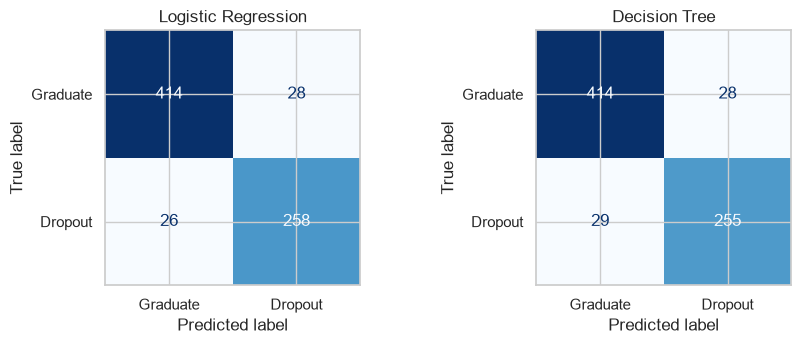

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
for a, (name, model) in zip(ax, [("Logistic Regression", logreg), ("Decision Tree", tree.best_estimator_)]):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=["Graduate", "Dropout"], cmap="Blues", ax=a, colorbar=False)
    a.set_title(name)
plt.tight_layout(); plt.show()

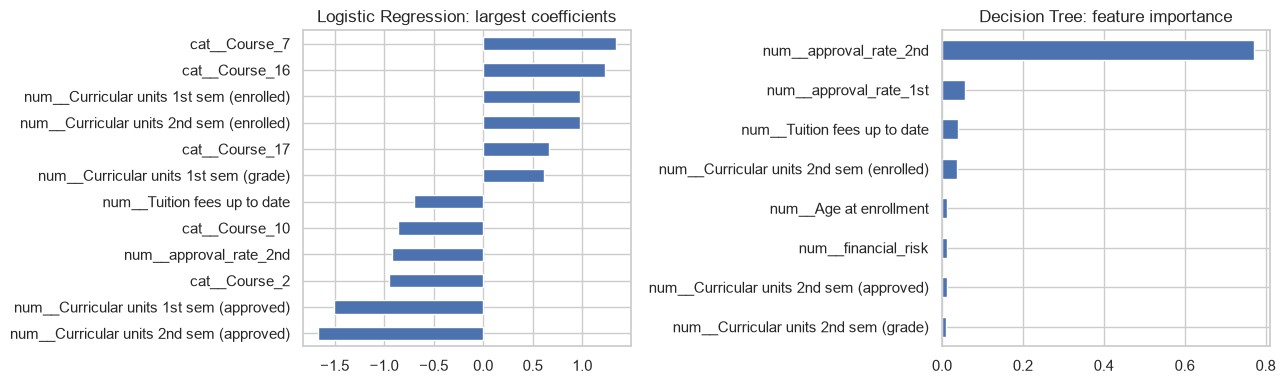

In [18]:
names = logreg.named_steps["prep"].get_feature_names_out()
coef = pd.Series(logreg.named_steps["model"].coef_[0], index=names)
imp = pd.Series(tree.best_estimator_.named_steps["model"].feature_importances_, index=names)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
pd.concat([coef.nlargest(6), coef.nsmallest(6)]).sort_values().plot.barh(ax=ax[0], color="#4C72B0")
ax[0].set_title("Logistic Regression: largest coefficients")
imp.nlargest(8).sort_values().plot.barh(ax=ax[1], color="#4C72B0")
ax[1].set_title("Decision Tree: feature importance")
plt.tight_layout(); plt.show()

**Confusion matrices (test set, 726 students).** Logistic Regression: 414 graduates and 258 dropouts predicted correctly, 28 false alarms, 26 missed dropouts. Decision Tree: the same 414 / 28 for graduates, 255 dropouts found and 29 missed.

**Which model is best?** **Logistic Regression** is slightly better on every metric: accuracy 0.926 vs 0.921, recall 0.908 vs 0.898, F1 0.905 vs 0.899. The difference is small (3 students), so both models are good; the tree is easier to explain as rules, the logistic regression is more accurate and more stable (train accuracy 0.909 ≈ test accuracy 0.926, no overfitting; the tree needed a depth limit of 8 and at least 10 students per leaf).

**Most important metric.** **Recall** of the dropout class: a missed student at risk is a lost student, while a false alarm costs only one advisor call. Both models find about 90 % of real dropouts, and the precision of 0.90 means 9 of 10 calls go to students who really need them.

**What the models learned.** Both models agree: the strongest signals are the approved units and the approval rate in the 2nd semester (the tree gives `approval_rate_2nd` 77 % of all importance), then the 1st semester results, tuition payment and financial risk, age and the course. This matches the EDA.

## 9. Conclusion

* **Data:** 4 424 students of a Portuguese university (Kaggle, CC0). 794 still-enrolled students were removed, giving 3 630 students with a known result: 61 % graduated, 39 % dropped out.
* **Preparation:** no missing values or duplicates; column typo fixed; 15 weak or almost constant features removed (nationality, parents' codes, macro-economics, rare unit counts); 3 features created (`approval_rate_1st`, `approval_rate_2nd`, `financial_risk`), which became the most important ones. Coded categories were one-hot encoded and numeric features scaled inside a pipeline.
* **Models:** Logistic Regression (baseline) and Decision Tree (depth 8, min 10 students per leaf, chosen by cross-validation).
* **Results (test):** Logistic Regression – accuracy 0.926, precision 0.902, recall 0.908, F1 0.905; Decision Tree – 0.921 / 0.901 / 0.898 / 0.899. Best model: Logistic Regression.
* **Business criteria:** met. Recall 0.908 ≥ 0.80, F1 0.905 ≥ 0.80, accuracy 0.926 is much better than the naive 0.61. The university can find about 9 of 10 future dropouts at the end of the first year with few false alarms.
* **Limitations and future work:** (1) the model uses the results of two semesters, so the warning comes only after the first year – a version that uses only 1st-semester data would help earlier; (2) the data is from one Portuguese university, for a Kazakhstan university the model must be retrained on local data; (3) the probability threshold is 0.5 – it can be lowered to increase recall if the university prefers more calls to more lost students; (4) ensemble models (Random Forest, Gradient Boosting) could add a few percent of accuracy.

**References:** Realinho V., Machado J., Baptista L., Martins M. V. (2022). *Predicting Student Dropout and Academic Success*. Data 7(11), 146; Kaggle dataset link above; scikit-learn documentation (LogisticRegression, DecisionTreeClassifier, Pipeline); James G. et al. *An Introduction to Statistical Learning*, ch. 4 and 8.